In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import json
import cv2
from scipy.spatial.distance import euclidean
from tqdm import tqdm


In [3]:
df1 = pd.read_csv("sub-4a2_ses-rest_task-calib_cam-1_rawframes.csv")['timestamp'].to_numpy()
df2 = pd.read_csv("sub-4a2_ses-rest_task-calib_cam-2_rawframes.csv")['timestamp'].to_numpy()
df3 = pd.read_csv("sub-4a2_ses-rest_task-calib_cam-3_rawframes.csv")['timestamp'].to_numpy()
df4 = pd.read_csv("sub-4a2_ses-rest_task-calib_cam-4_rawframes.csv")['timestamp'].to_numpy()
ref = pd.read_csv("sub-4a2_ses-rest_task-calib_refframes.csv")['timestamp'].to_numpy()

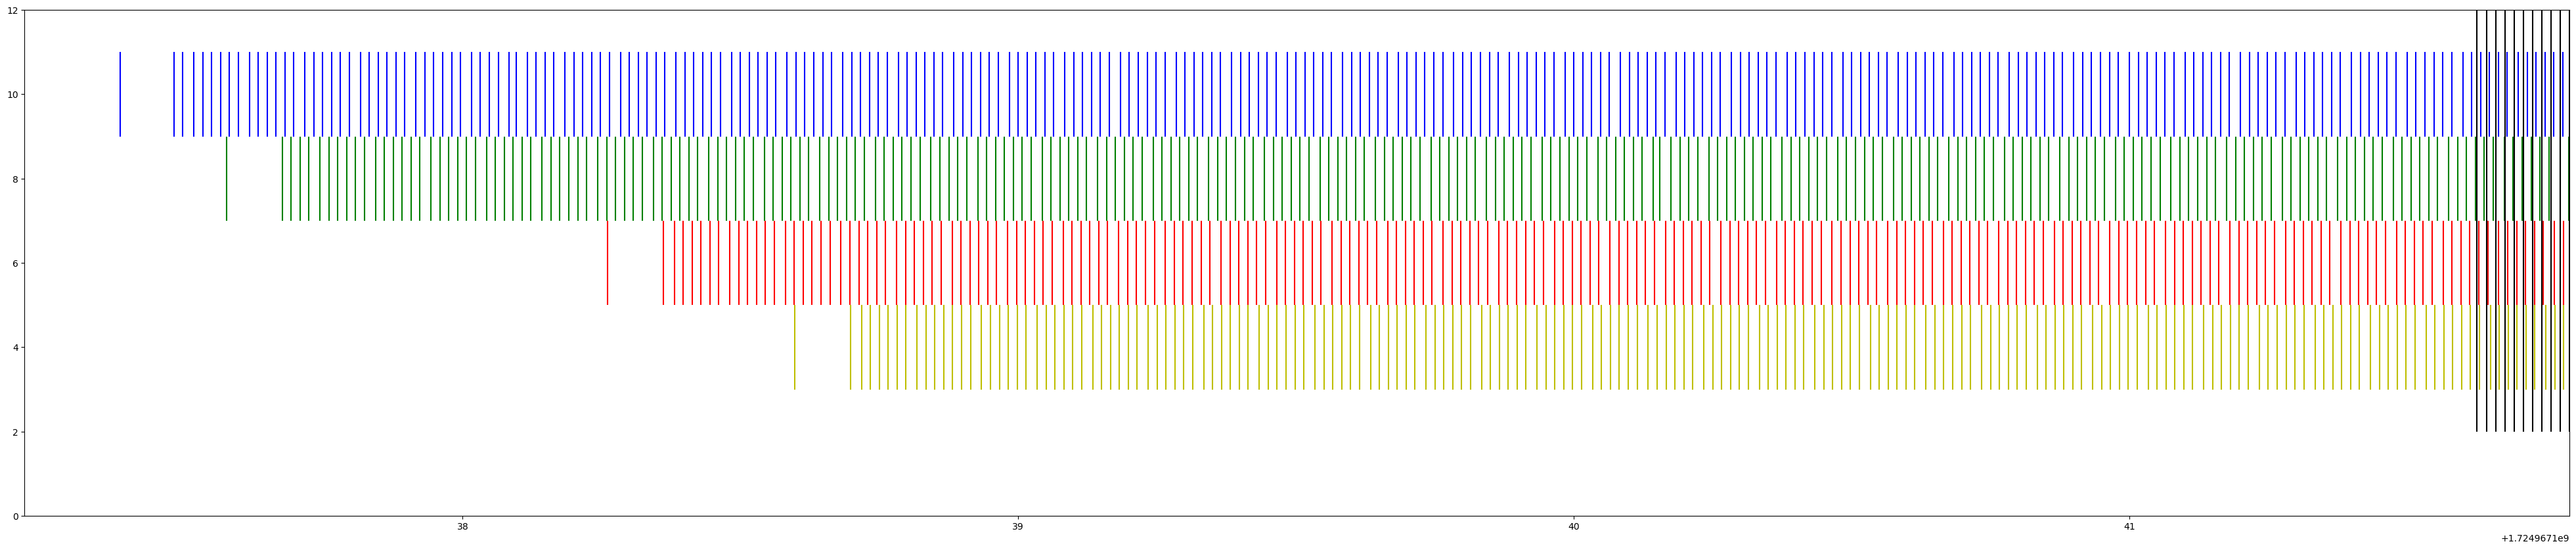

In [9]:
fig, ax = plt.subplots(figsize=(50, 10))
ax.eventplot([df1, df2, df3, df4, ref], colors=['b', 'g', 'r', 'y', 'black'], lineoffsets=[10, 8, 6, 4, 7], linelengths=[2, 2, 2, 2, 10])
ax.set_xlim(min(df1[0], df2[0], df3[0], df4[0]) *(0.9999999999) , ref[10])
ax.set_ylim(0, 12)
plt.show()

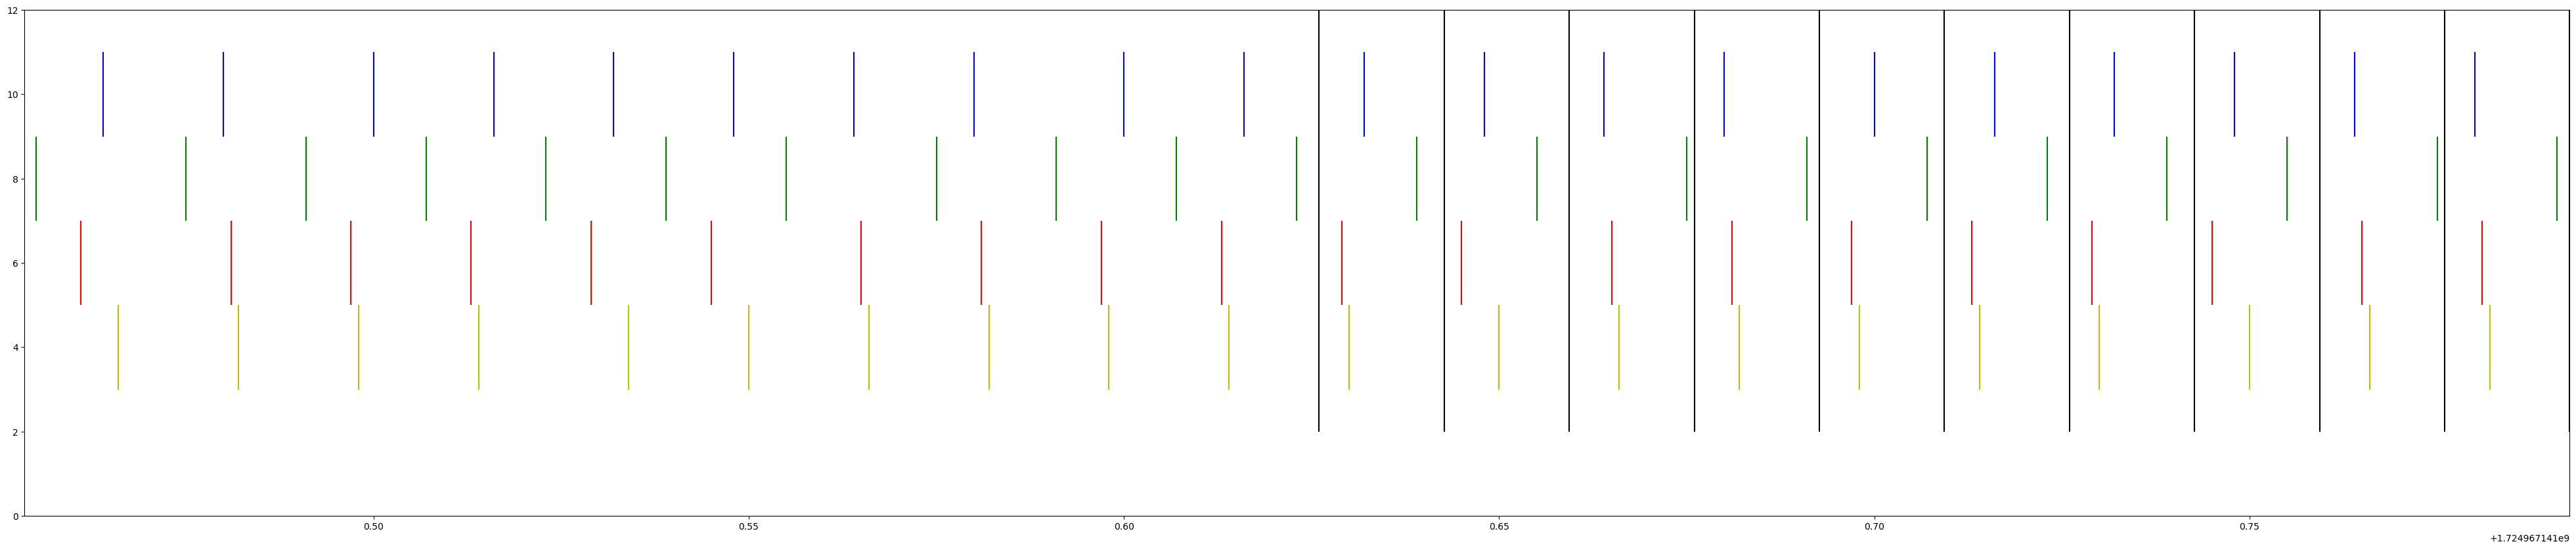

In [10]:
fig, ax = plt.subplots(figsize=(50, 10))
ax.eventplot([df1, df2, df3, df4, ref], colors=['b', 'g', 'r', 'y', 'black'], lineoffsets=[10, 8, 6, 4, 7], linelengths=[2, 2, 2, 2, 10])
ax.set_xlim(ref[0]*(0.9999999999) , ref[10])
ax.set_ylim(0, 12)
plt.show()

In [12]:
create_video_grid(['sub-4a2_ses-rest_task-calib_cam-1_video.mp4', 'sub-4a2_ses-rest_task-calib_cam-2_video.mp4', 'sub-4a2_ses-rest_task-calib_cam-3_video.mp4', 'sub-4a2_ses-rest_task-calib_cam-4_video.mp4'], 'synced.mp4')

In [5]:
import cv2
import numpy as np
import math

def create_video_grid(video_paths, output_path):
    num_videos = len(video_paths)
    grid_size = math.ceil(math.sqrt(num_videos))  # Calculate grid size (e.g., 2x2 for 4 videos)

    # Open all video captures
    caps = [cv2.VideoCapture(video) for video in video_paths]

    # Get frame dimensions from the first video
    frame_width = int(caps[0].get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(caps[0].get(cv2.CAP_PROP_FRAME_HEIGHT))
    frame_rate = int(caps[0].get(cv2.CAP_PROP_FPS))

    # Calculate output video dimensions
    output_width = frame_width * grid_size
    output_height = frame_height * grid_size

    # Output video writer
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, frame_rate, (output_width, output_height))

    while True:
        frames = []
        for cap in caps:
            ret, frame = cap.read()
            if not ret:
                break
            frames.append(frame)

        if len(frames) != num_videos:
            break

        # Resize all frames to the size of the first video (if needed)
        frames = [cv2.resize(frame, (frame_width, frame_height)) for frame in frames]

        # Create an empty grid
        grid_frame = np.zeros((output_height, output_width, 3), dtype=np.uint8)

        # Place each frame into the correct position in the grid
        for idx, frame in enumerate(frames):
            row = idx // grid_size
            col = idx % grid_size
            start_y = row * frame_height
            start_x = col * frame_width
            grid_frame[start_y:start_y + frame_height, start_x:start_x + frame_width] = frame

        # Write the grid frame to the output video
        out.write(grid_frame)

        # Optionally display the grid frame
        # cv2.imshow('Grid', grid_frame)
        # if cv2.waitKey(1) & 0xFF == ord('q'):
        #     break

    # Release all resources
    for cap in caps:
        cap.release()
    out.release()
    # cv2.destroyAllWindows()